# Student Performance Analysis — Portuguese course

A reproducible descriptive workflow using Python and Pandas. The response variable is final Portuguese grade `G3` (0–20). Associations are not causal effects. The dataset contains no test-preparation or attendance-percentage field; `schoolsup` means extra educational support.

Run from this notebook directory or project root. It reads `data/raw/student-por.csv` relative to the project and regenerates results and figures.

## 1. Imports and data loading

The reusable loader standardizes strings, converts numeric fields, and applies documented validity checks.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT / 'src'))
from analysis import load_clean_data, run

df = load_clean_data(PROJECT / 'data/raw/student-por.csv')
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (649, 37)


,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,walc,health,absences,g1,g2,g3,performance_category,attendance_category,studytime_label,grade_change_g1_g3
0,gp,f,18.0,u,gt3,a,4.0,4.0,at_home,teacher,...,1.0,3.0,4.0,0.0,11.0,11.0,Average,Higher attendance (0–4 absences),2–5 hours/week,11.0
1,gp,f,17.0,u,gt3,t,1.0,1.0,at_home,other,...,1.0,3.0,2.0,9.0,11.0,11.0,Average,Higher attendance (0–4 absences),2–5 hours/week,2.0
2,gp,f,15.0,u,le3,t,1.0,1.0,at_home,other,...,3.0,3.0,6.0,12.0,13.0,12.0,Average,Moderate (5–10),2–5 hours/week,0.0
3,gp,f,15.0,u,gt3,t,4.0,2.0,health,services,...,1.0,5.0,0.0,14.0,14.0,14.0,Good,Higher attendance (0–4 absences),5–10 hours/week,0.0
4,gp,f,16.0,u,gt3,t,3.0,3.0,other,other,...,2.0,5.0,0.0,11.0,13.0,13.0,Average,Higher attendance (0–4 absences),2–5 hours/week,2.0


## 2. Data understanding and quality

Inspect types, missingness, duplicate rows, unique values, descriptive statistics, and grade range before interpreting group patterns.

In [2]:
df.info()
display(df.isna().sum().sort_values(ascending=False).head(10))
print('Exact duplicate rows:', df.duplicated().sum())
display(df.nunique().sort_values())
display(df.describe(include='all').T)

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   school                649 non-null    str     
 1   sex                   649 non-null    str     
 2   age                   649 non-null    float64 
 3   address               649 non-null    str     
 4   famsize               649 non-null    str     
 5   pstatus               649 non-null    str     
 6   medu                  649 non-null    float64 
 7   fedu                  649 non-null    float64 
 8   mjob                  649 non-null    str     
 9   fjob                  649 non-null    str     
 10  reason                649 non-null    str     
 11  guardian              649 non-null    str     
 12  traveltime            649 non-null    float64 
 13  studytime             649 non-null    float64 
 14  failures              649 non-null    int64   
 15  schoolsup        

school     0
sex        0
age        0
address    0
famsize    0
pstatus    0
medu       0
fedu       0
mjob       0
fjob       0
dtype: int64

Exact duplicate rows: 0


school                   2
sex                      2
address                  2
famsize                  2
pstatus                  2
schoolsup                2
paid                     2
famsup                   2
nursery                  2
romantic                 2
internet                 2
higher                   2
activities               2
guardian                 3
attendance_category      3
studytime                4
failures                 4
reason                   4
performance_category     4
traveltime               4
studytime_label          4
medu                     5
freetime                 5
mjob                     5
health                   5
goout                    5
dalc                     5
walc                     5
fedu                     5
fjob                     5
famrel                   5
age                      8
g2                      16
g1                      17
grade_change_g1_g3      17
g3                      17
absences                24
d

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,gp,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,f,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,u,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,gt3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pstatus,649,2,t,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Cleaning and feature engineering

The loader keeps valid observations, flags impossible grades/ages/absences as missing, and does not impute. Score bands are descriptive: Low 0–9, Average 10–13, Good 14–16, Excellent 17–20. Attendance bands use absence counts (0–4, 5–10, 11+), not attendance rates.

In [3]:
display(df[['g1','g2','g3','studytime','studytime_label','absences','attendance_category','performance_category','grade_change_g1_g3']].head())
display(df.performance_category.value_counts(sort=False).to_frame('students').assign(percent=lambda x: x.students / len(df) * 100))

,g1,g2,g3,studytime,studytime_label,absences,attendance_category,performance_category,grade_change_g1_g3
0,0.0,11.0,11.0,2.0,2–5 hours/week,4.0,Higher attendance (0–4 absences),Average,11.0
1,9.0,11.0,11.0,2.0,2–5 hours/week,2.0,Higher attendance (0–4 absences),Average,2.0
2,12.0,13.0,12.0,2.0,2–5 hours/week,6.0,Moderate (5–10),Average,0.0
3,14.0,14.0,14.0,3.0,5–10 hours/week,0.0,Higher attendance (0–4 absences),Good,0.0
4,11.0,13.0,13.0,2.0,2–5 hours/week,0.0,Higher attendance (0–4 absences),Average,2.0


,students,percent
performance_category,,
Low,100,15.408320
Average,355,54.699538
Good,148,22.804314
Excellent,46,7.087827


## 4. Overall performance and factor summaries

The script produces category counts, grouped score summaries, numerical correlations, test statistics, and eight saved visualizations.

In [4]:
clean_df, metrics = run()
display(clean_df.g3.describe())
display(clean_df.groupby('studytime_label', observed=False).g3.agg(['count','mean','median','std']))
display(clean_df.groupby('attendance_category', observed=False).g3.agg(['count','mean','median','std']))
display(clean_df.groupby('schoolsup').g3.agg(['count','mean','median','std']))

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: g3, dtype: float64

,count,mean,median,std
studytime_label,,,,
2–5 hours/week,305,12.091803,12.0,3.243125
5–10 hours/week,97,13.226804,13.0,2.502104
<2 hours/week,212,10.844340,11.0,3.218624
>10 hours/week,35,13.057143,13.0,3.038410


,count,mean,median,std
attendance_category,,,,
Higher attendance (0–4 absences),466,12.055794,12.0,3.426196
Moderate (5–10),134,11.843284,11.0,2.649598
Lower attendance (11+),49,10.653061,10.0,2.428571


,count,mean,median,std
schoolsup,,,,
no,581,11.979346,12.0,3.316040
yes,68,11.279412,11.0,2.304088


## 5. Relationship and statistical analysis

Pearson correlation summarizes linear numeric association. Kruskal–Wallis compares score distributions across four study-time groups. Welch's t-test compares group means for extra school-support status (not test preparation). Group differences can reflect selection and confounding.

G1/G2 are prior-period grades in the same subject; their strong relationship with G3 is descriptive and not evidence that changing those grades would cause a particular final outcome.

In [5]:
display(pd.Series(metrics['correlations_with_g3'], name='Pearson r with G3'))
print('G2–G3 Pearson r:', round(metrics['g2_g3_pearson_r'], 3), 'p=', metrics['g2_g3_p'])
print('Study-time Kruskal–Wallis H:', round(metrics['studytime_kruskal_h'], 3), 'p=', metrics['studytime_kruskal_p'])
print('School support Welch t:', round(metrics['schoolsup_welch_t'], 3), 'p=', metrics['schoolsup_welch_p'])

g2            0.918548
g1            0.826387
failures     -0.393316
studytime     0.249789
medu          0.240151
fedu          0.211800
dalc         -0.204719
walc         -0.176619
traveltime   -0.127173
freetime     -0.122705
age          -0.106505
health       -0.098851
absences     -0.091379
goout        -0.087641
famrel        0.063361
Name: Pearson r with G3, dtype: float64

G2–G3 Pearson r: 0.919 p= 5.6424014895885155e-263
Study-time Kruskal–Wallis H: 50.316 p= 6.841570528918375e-11
School support Welch t: -2.247 p= 0.026753318027728592


## 6. Outliers, figures, and interpretation

IQR flags are retained for review rather than automatically removed. Review `results/metrics.json`, CSV summary tables, and `visualizations/` for reproducible results. Note that the raw data are observational and limited to two Portuguese schools in 2005–2006.

attendance_vs_score.png


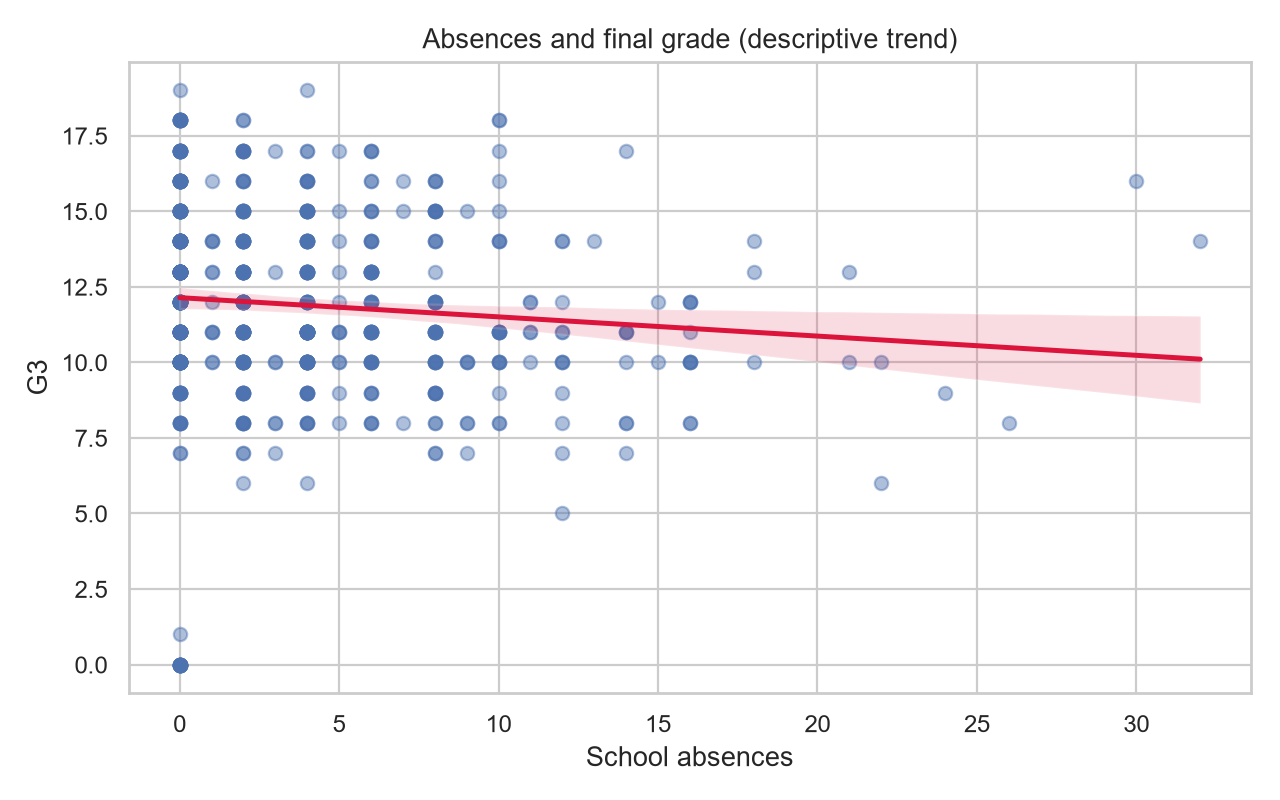

correlation_heatmap.png


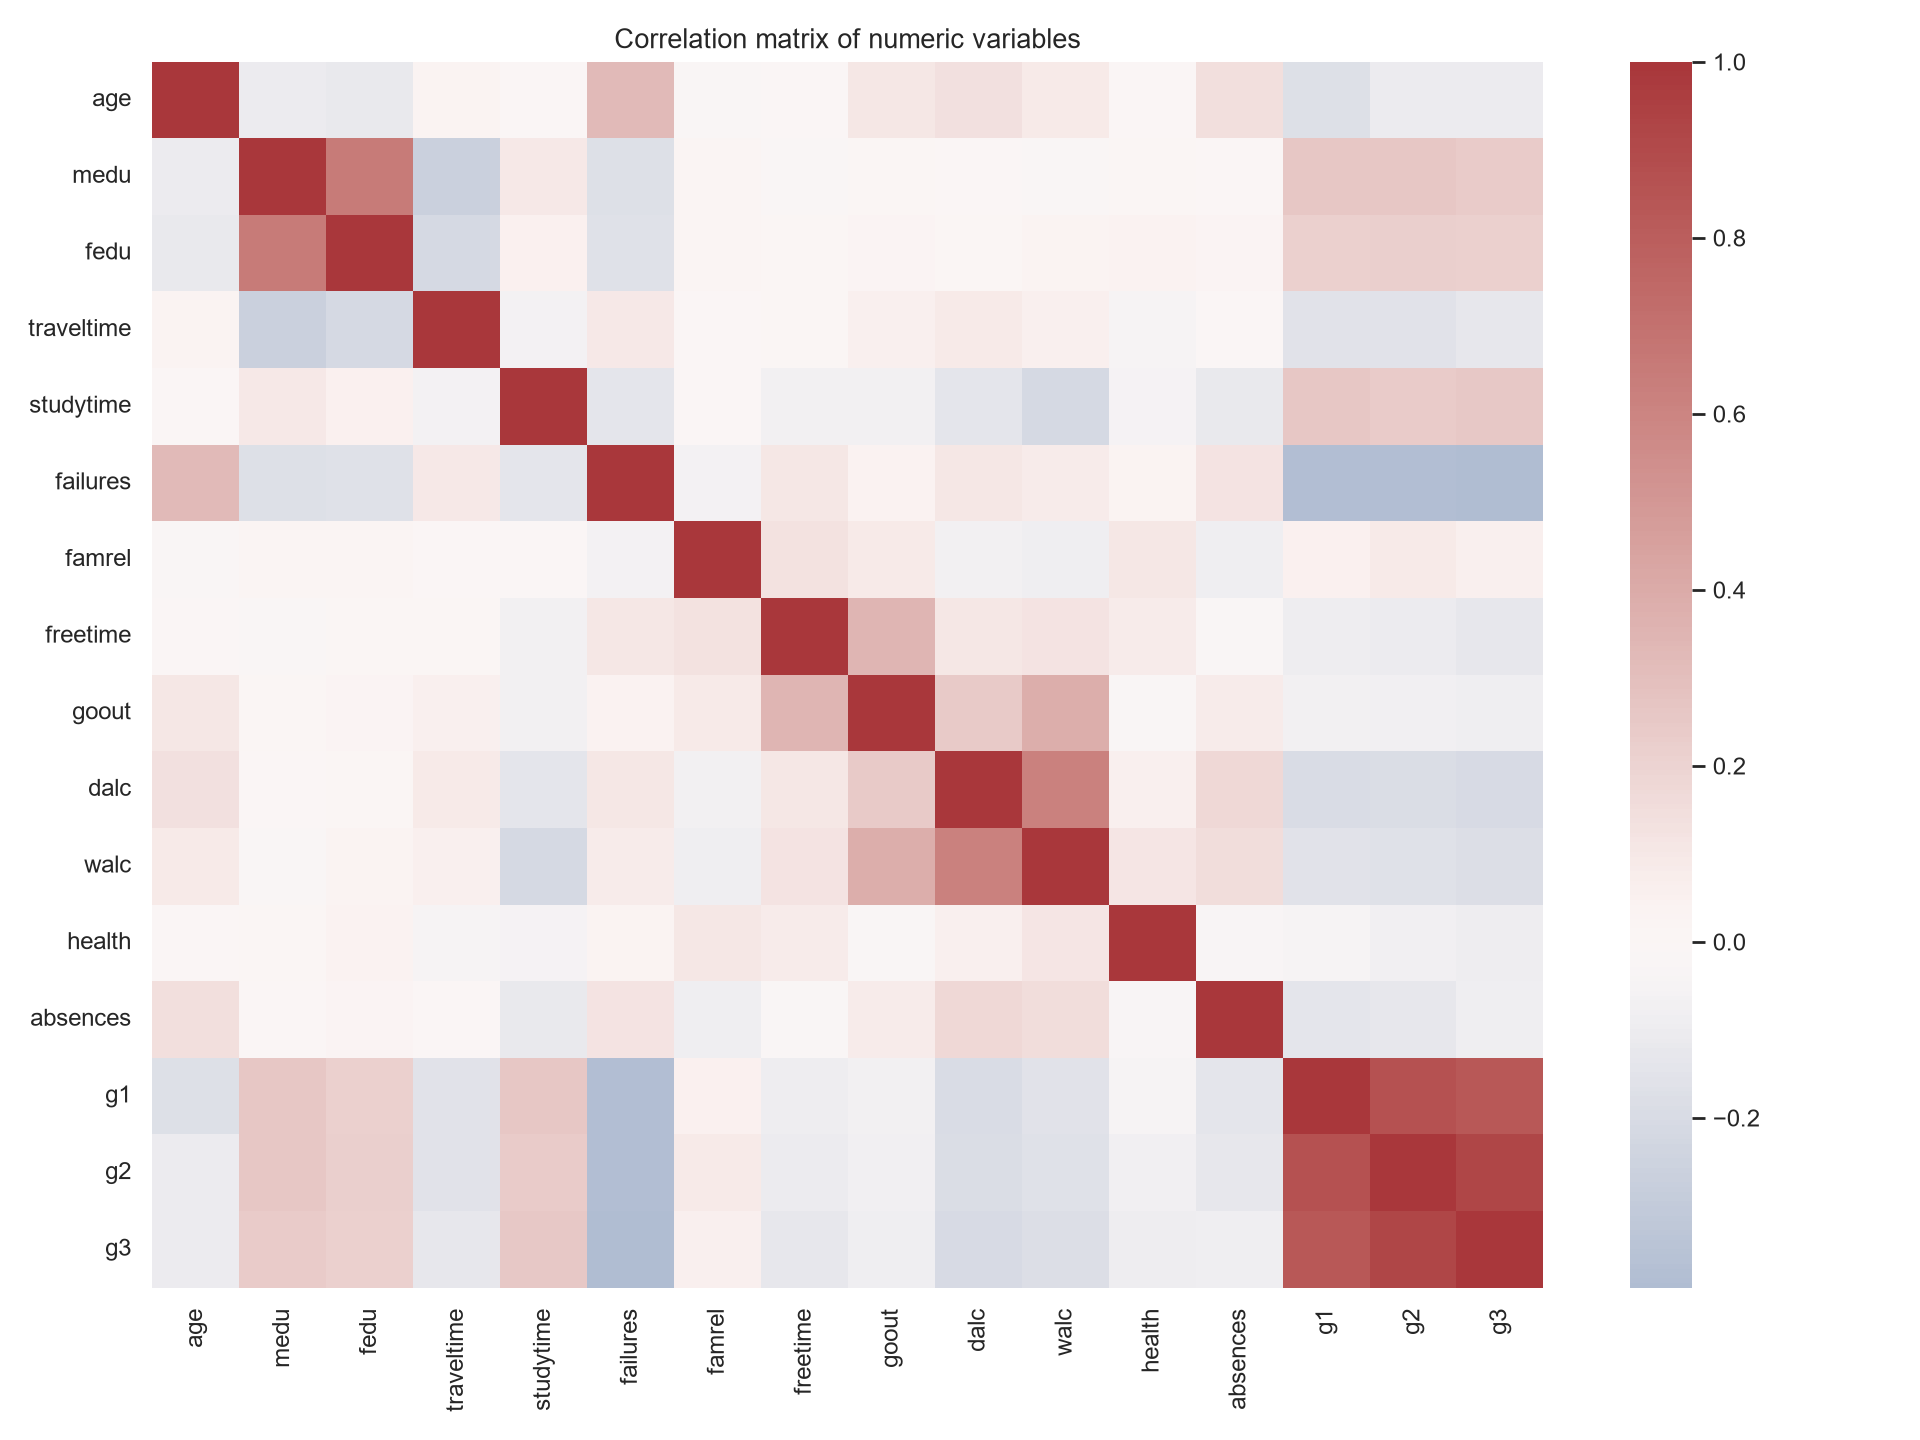

parental_education_analysis.png


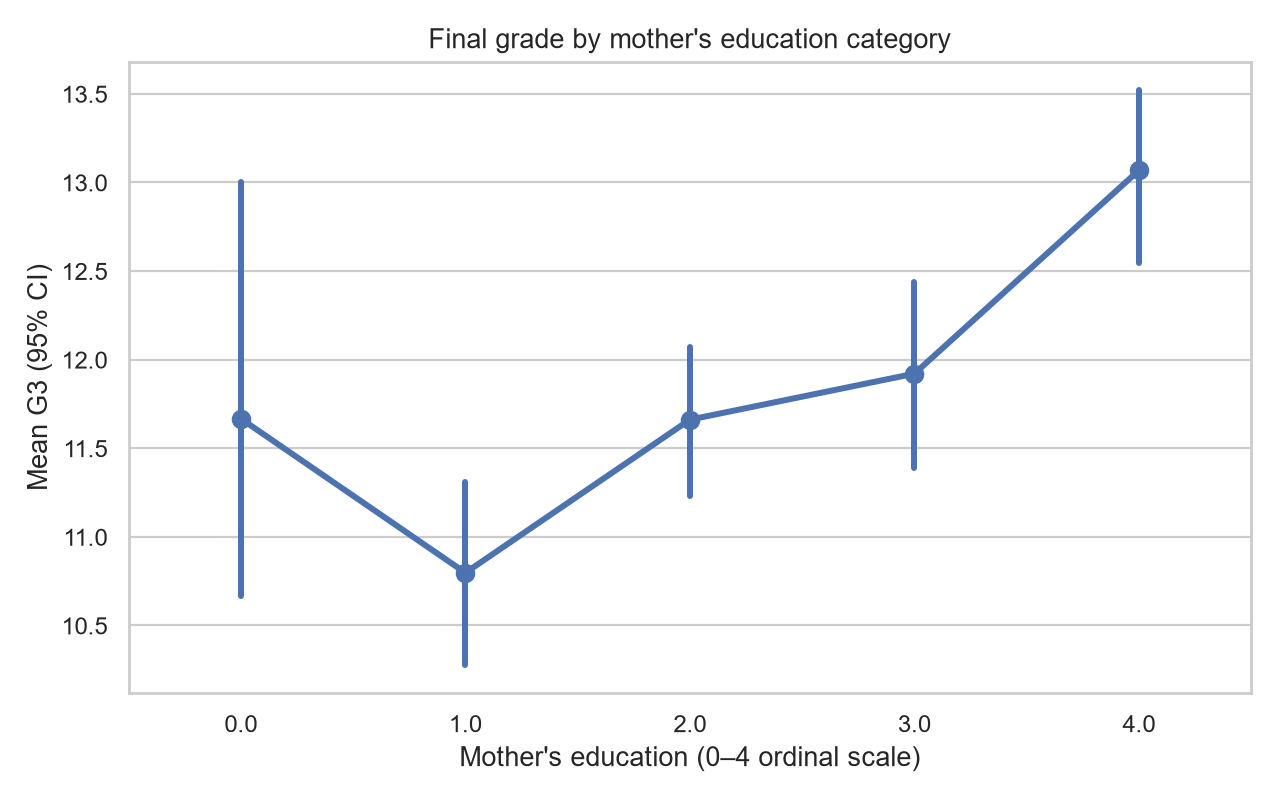

performance_categories.png


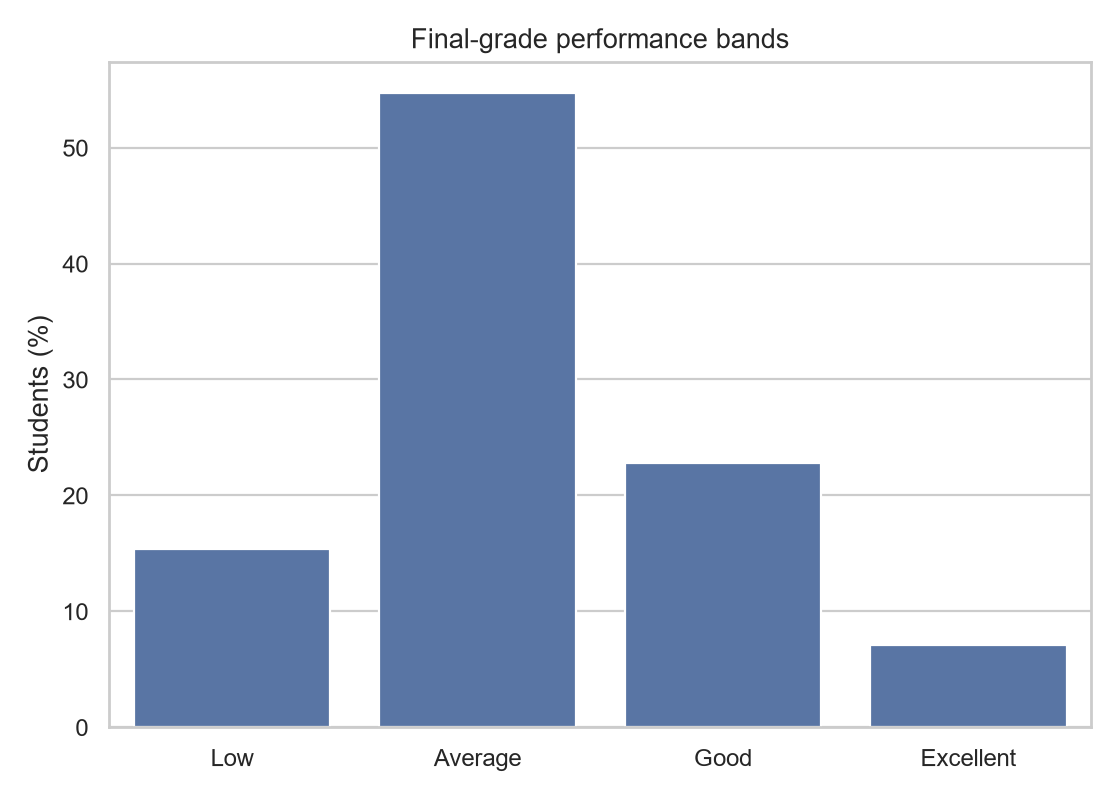

previous_vs_current_score.png


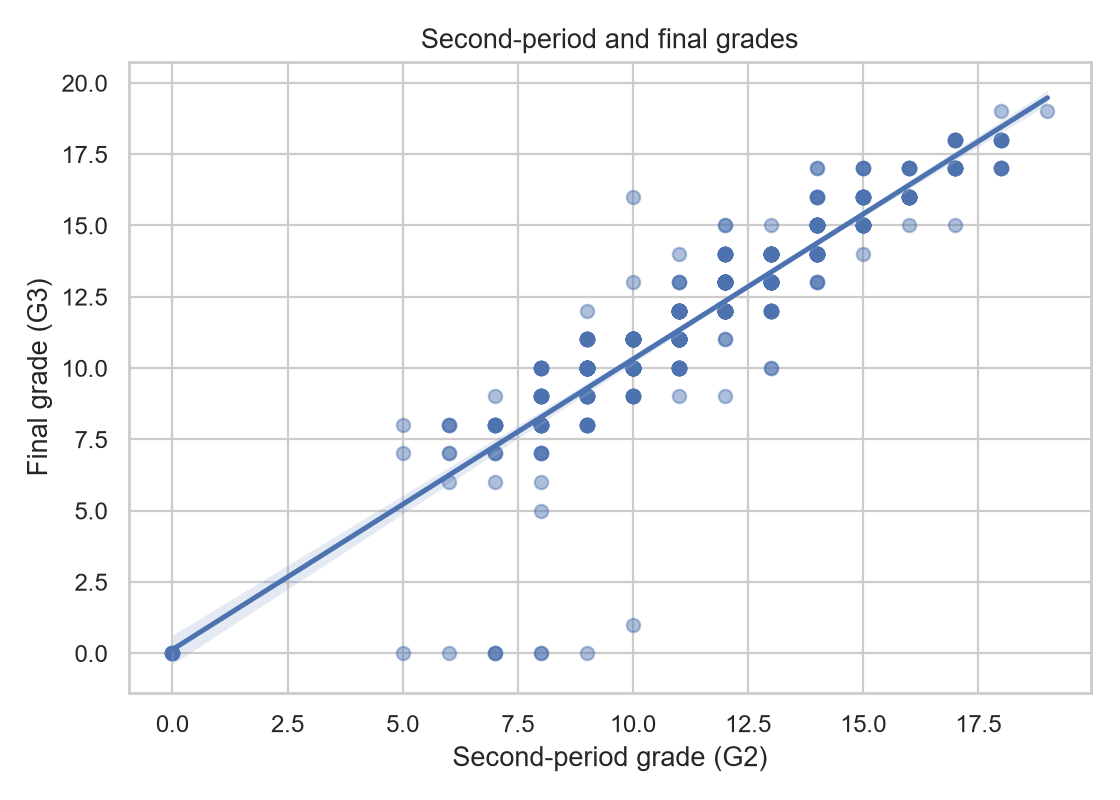

school_support_analysis.png


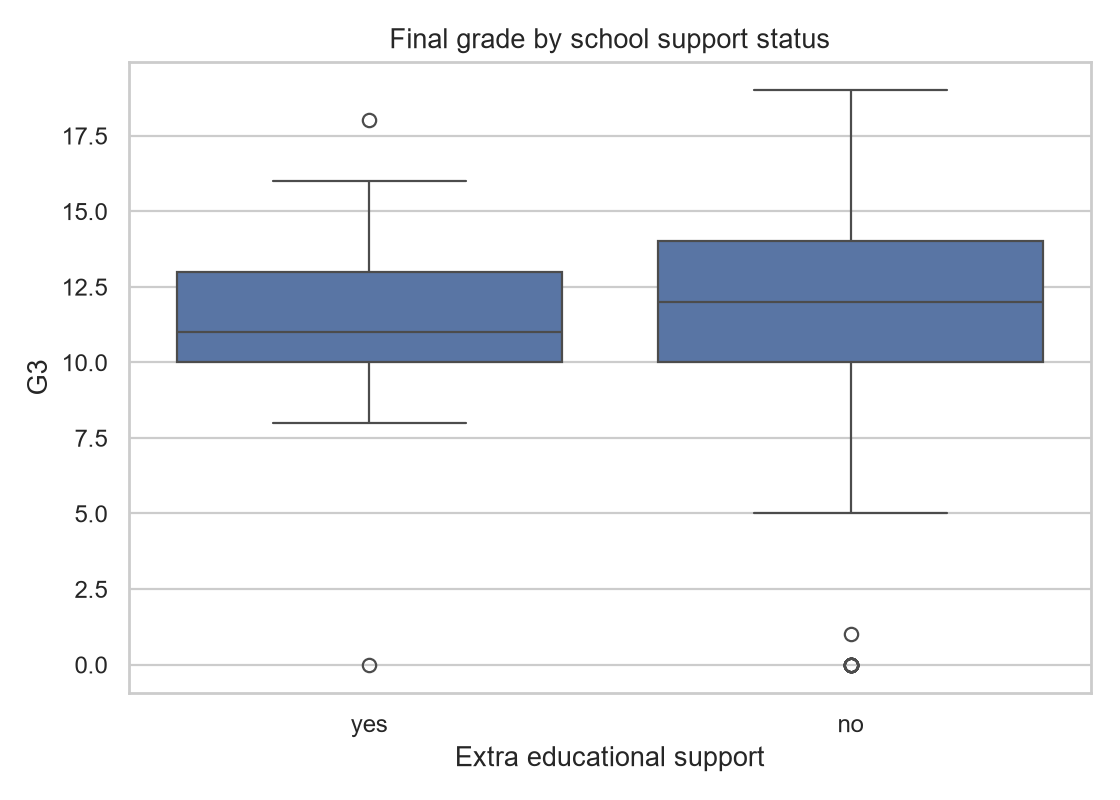

score_distribution.png


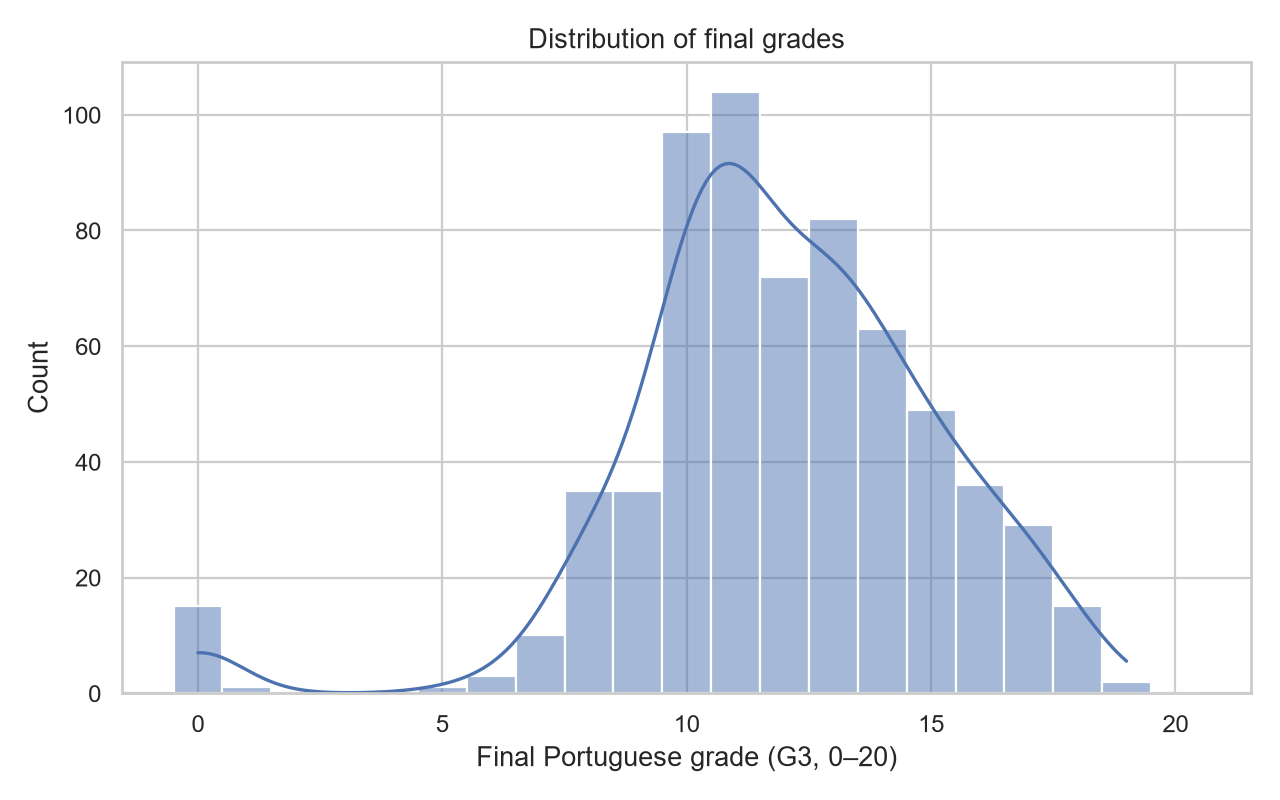

studytime_vs_score.png


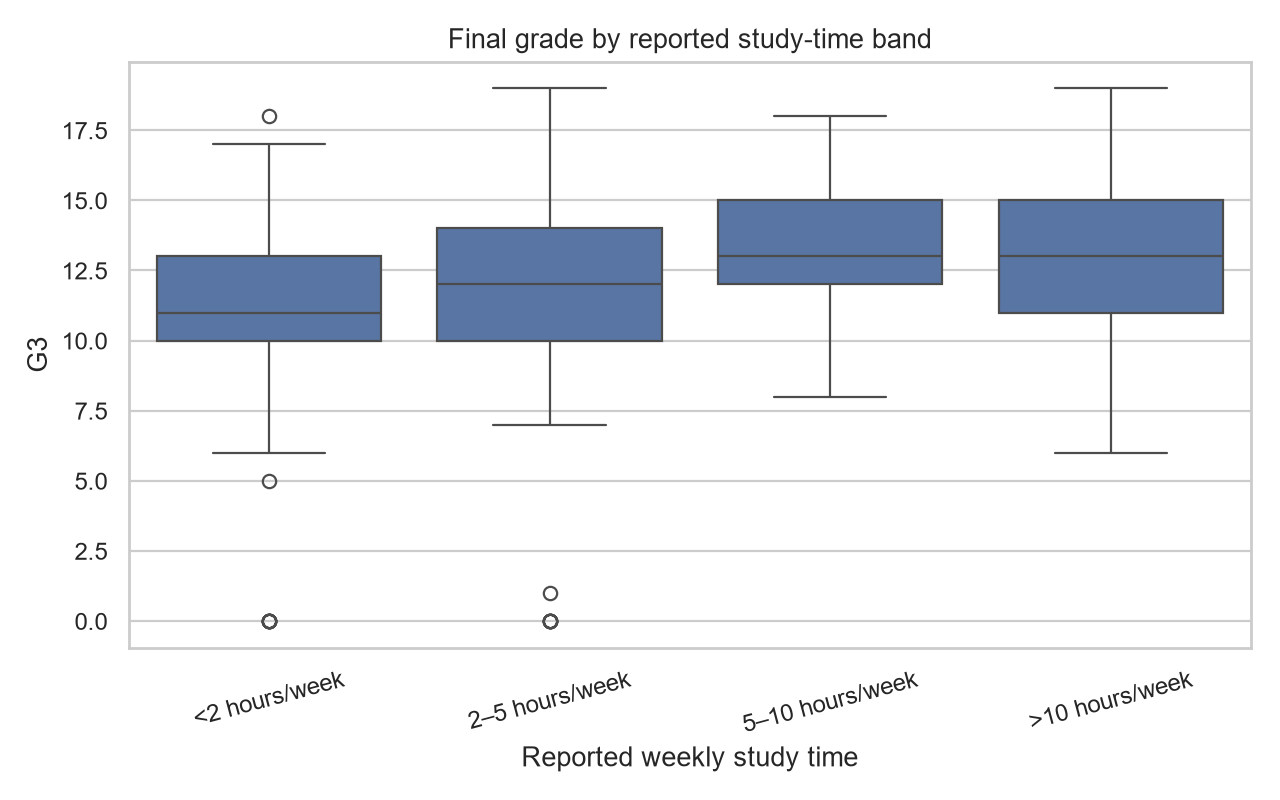

In [6]:
from IPython.display import Image, display
for name in sorted((PROJECT / 'visualizations').glob('*.png')):
    print(name.name)
    display(Image(filename=str(name)))